# ECC Benchmarking Suite
### KeyGeneration · Encrypt · Decrypt

**Setup requirements:**  
- SageMath installed and `sage` available on `PATH`  
- `KeyGeneration.py`, `Encrypt.py`, `Decrypt.py` in the **same directory** as this notebook  
- `pip install matplotlib numpy`

Each benchmark calls the sage scripts via `subprocess`, parses the printed `Time Taken` value, and plots the results.

In [1]:
import subprocess
import re
import os
import json
import time
import tempfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Configuration ──────────────────────────────────────────────────────────────
SAGE        = "python"          # change to full path if sage is not on PATH
SCRIPT_DIR  = Path(".")       # directory containing the .py scripts
RUNS        = 5               # repetitions per data-point (median is used)
TIMEOUT     = 600             # seconds before a single run is aborted

plt.rcParams.update({
    "figure.dpi":     130,
    "font.family":    "sans-serif",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.35,
})

COLOURS = ["#3B82F6", "#EF4444", "#10B981", "#F59E0B", "#8B5CF6", "#EC4899"]

print("✓ Imports OK")

✓ Imports OK


In [2]:
# ── Helper utilities ───────────────────────────────────────────────────────────

def run_sage(args: list[str], cwd=None, timeout=TIMEOUT) -> tuple[str, float | None]:
    """Run `sage <args>` and return (stdout, parsed_time_seconds | None)."""
    cmd = [SAGE] + args
    try:
        result = subprocess.run(
            cmd, capture_output=True, text=True,
            cwd=str(cwd or SCRIPT_DIR), timeout=timeout
        )
        stdout = result.stdout + result.stderr
        m = re.search(r"Time Taken[:\s]+([\d.]+)s", stdout)
        elapsed = float(m.group(1)) if m else None
        if result.returncode != 0 and elapsed is None:
            print(f"  [WARN] non-zero exit ({result.returncode}): {stdout[:200]}")
        return stdout, elapsed
    except subprocess.TimeoutExpired:
        print(f"  [TIMEOUT] {' '.join(cmd)}")
        return "", None


def median_time(args: list[str], runs=RUNS, cwd=None) -> float | None:
    """Run RUNS times and return the median time (ignoring failed runs)."""
    times = []
    for _ in range(runs):
        _, t = run_sage(args, cwd=cwd)
        if t is not None:
            times.append(t)
    return float(np.median(times)) if times else None


def make_tmpdir() -> Path:
    """Create a temp directory pre-populated with the sage scripts."""
    tmpdir = Path(tempfile.mkdtemp())
    for script in ["KeyGeneration.py", "Encrypt.py", "Decrypt.py"]:
        src = SCRIPT_DIR / script
        if src.exists():
            shutil.copy(src, tmpdir / script)
    return tmpdir


def cleanup(tmpdir: Path):
    shutil.rmtree(str(tmpdir), ignore_errors=True)


print("✓ Helpers OK")

✓ Helpers OK


In [20]:
run_sage(["KeyGeneration.py", "3", "352", "1"])

('Time Taken: 7.082s\n', 7.082)

---
## 1  KeyGeneration — Key Size vs Time

Uses **Mode 3** (`bits`, `degree=1`) to sweep over a range of prime-field bit sizes.  
Predefined curves (Mode 2) are also included as reference points.

> ⚠️ Larger bit sizes (256 +) can take minutes. Adjust `BIT_SIZES` to taste.

In [17]:
# ── Bit sizes to sweep ─────────────────────────────────────────────────────────
BIT_SIZES = [32, 48, 64, 80, 96, 112, 128, 160, 192, 224, 256, 288, 320, 352, 384]
# Remove large sizes if you want faster runs:
# BIT_SIZES = [32, 48, 64, 80, 96, 128]

PREDEFINED = [
    ("secp256k1", 256),
    ("P-256",     256),
    ("curve25519",255),
]

keygen_times   = []   # (bits, time)
predefined_pts = []   # (bits, time, name)

print("Benchmarking KeyGeneration (Mode 3) …")
for bits in BIT_SIZES:
    t = median_time(["KeyGeneration.py", "3", str(bits), "1"])
    keygen_times.append((bits, t))
    status = f"{t:.3f}s" if t is not None else "FAILED"
    print(f"  bits={bits:>3}  →  {status}")

print("\nBenchmarking predefined curves (Mode 2) …")
for name, bits in PREDEFINED:
    t = median_time(["KeyGeneration.py", "2", name])
    predefined_pts.append((bits, t, name))
    status = f"{t:.3f}s" if t is not None else "FAILED"
    print(f"  {name:<12}  →  {status}")

print("\n✓ KeyGeneration benchmark done")

Benchmarking KeyGeneration (Mode 3) …
  bits= 32  →  0.012s
  bits= 48  →  0.013s
  bits= 64  →  0.036s
  bits= 80  →  0.057s
  bits= 96  →  0.070s
  bits=112  →  0.092s
  bits=128  →  0.119s
  bits=160  →  0.252s
  bits=192  →  0.717s
  bits=224  →  0.946s
  bits=256  →  2.037s
  bits=288  →  2.384s
  bits=320  →  4.850s
  [TIMEOUT] python KeyGeneration.py 3 352 1
  bits=352  →  59.554s
  [TIMEOUT] python KeyGeneration.py 3 384 1
  [TIMEOUT] python KeyGeneration.py 3 384 1
  bits=384  →  11.675s

Benchmarking predefined curves (Mode 2) …
  secp256k1     →  0.150s
  P-256         →  0.054s
  curve25519    →  0.113s

✓ KeyGeneration benchmark done


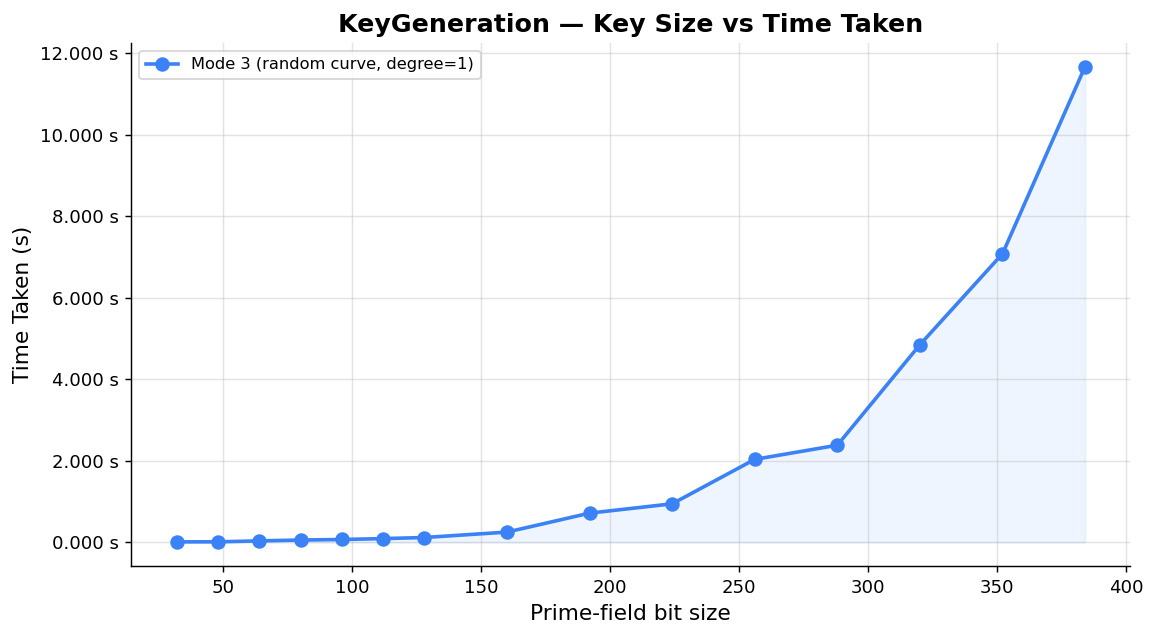

Saved → bench_keygen.png


In [3]:
# ── Plot ────────────────────────────────────────────────────────────────────────
valid = [(b, t) for b, t in keygen_times if t is not None]
xs, ys = zip(*valid) if valid else ([], [])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(xs, ys, "o-", color=COLOURS[0], linewidth=2,
        markersize=7, label="Mode 3 (random curve, degree=1)")

# Shade area under curve
ax.fill_between(xs, ys, alpha=0.08, color=COLOURS[0])

# Predefined curve markers
"""for bits, t, name in predefined_pts:
    if t is not None:
        ax.scatter([bits], [t], zorder=5, s=90, marker="D",
                   color=COLOURS[1], label=f"{name} (Mode 2)")
        ax.annotate(name, (bits, t), textcoords="offset points",
                    xytext=(8, 4), fontsize=8, color=COLOURS[1])
"""

ax.set_xlabel("Prime-field bit size", fontsize=12)
ax.set_ylabel("Time Taken (s)", fontsize=12)
ax.set_title("KeyGeneration — Key Size vs Time Taken", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f s"))
plt.tight_layout()
plt.savefig("bench_keygen.png", dpi=150)
plt.show()
print("Saved → bench_keygen.png")

---
## 2  Encrypt — Message Size vs Time (multiple key sizes)

For each key size a fresh key-pair is generated, then messages of increasing length are encrypted.

In [25]:
from pathlib import Path
import numpy as np

# ── Parameters ─────────────────────────────────────────────────────────────────
KEY_BITS_TO_TEST = [64, 96, 128, 192, 256, 384]
MSG_SIZES_BYTES  = [10, 100, 1000, 5000, 10000, 20000, 30000, 50000, 75000, 100000] 
RUNS = 3 # Ensure RUNS is defined

# Load the sample text from big.txt as raw bytes
BIG_FILE_PATH = Path("big.txt")
if BIG_FILE_PATH.exists():
    # Reading as bytes automatically handles UTF-8 byte counts correctly
    SAMPLE_DATA = BIG_FILE_PATH.read_bytes()
else:
    print("Error: big.txt not found.")
    exit()

def make_message_file(path: Path, n_bytes: int) -> int:
    """Writes n_bytes to a file and returns the actual number of bytes written."""
    # Slice the data. This handles cases where n_bytes > file size.
    chunk = SAMPLE_DATA[:n_bytes]
    path.write_bytes(chunk)
    return len(chunk)

# Results: {bits: [(msg_bytes, time), ...]}
encrypt_results = {}

for bits in KEY_BITS_TO_TEST:
    print(f"\n── Key size: {bits} bits ──")
    tmpdir = make_tmpdir() # Assumes this helper exists in your script

    # 1. Generate keys for this bit size
    while True:
        _, kt = run_sage(["KeyGeneration.py", "3", str(bits), "1"], cwd=tmpdir)
        if kt is None:
            print(f"  Key generation FAILED for {bits} bits — skipping.")
            cleanup(tmpdir)
            continue
        print(f"  KeyGen: {kt:.3f}s")
        break

    times = []
    for n in MSG_SIZES_BYTES:
        msg_file = tmpdir / "message.txt"
        
        # Write file and get the exact byte count
        actual_byte_count = make_message_file(msg_file, n)

        run_times = []
        for _ in range(RUNS):
            _, t = run_sage(
                ["Encrypt.py", "1", "ecc_public_key.txt", "message.txt"],
                cwd=tmpdir
            )
            if t is not None:
                run_times.append(t)

        med = float(np.median(run_times)) if run_times else None
        
        # Store result using the actual byte count
        times.append((actual_byte_count, med))
        
        status = f"{med:.3f}s" if med is not None else "FAILED"
        print(f"  size={actual_byte_count:>5} bytes  →  {status}")

    encrypt_results[bits] = times
    cleanup(tmpdir)

print("\n✓ Encrypt benchmark done")


── Key size: 64 bits ──
  KeyGen: 0.038s
  size=   10 bytes  →  0.035s
  size=  100 bytes  →  0.037s
  size= 1000 bytes  →  0.053s
  size= 5000 bytes  →  0.110s
  size=10000 bytes  →  0.188s
  size=20000 bytes  →  0.352s
  size=30000 bytes  →  0.497s
  size=50000 bytes  →  0.824s
  size=75000 bytes  →  1.243s
  size=100000 bytes  →  1.562s

── Key size: 96 bits ──
  KeyGen: 0.083s
  size=   10 bytes  →  0.072s
  size=  100 bytes  →  0.074s
  size= 1000 bytes  →  0.087s
  size= 5000 bytes  →  0.133s
  size=10000 bytes  →  0.191s
  size=20000 bytes  →  0.304s
  size=30000 bytes  →  0.410s
  size=50000 bytes  →  0.654s
  size=75000 bytes  →  0.946s
  size=100000 bytes  →  1.225s

── Key size: 128 bits ──
  KeyGen: 0.129s
  size=   10 bytes  →  0.116s
  size=  100 bytes  →  0.120s
  size= 1000 bytes  →  0.130s
  size= 5000 bytes  →  0.167s
  size=10000 bytes  →  0.215s
  size=20000 bytes  →  0.302s
  size=30000 bytes  →  0.388s
  size=50000 bytes  →  0.562s
  size=75000 bytes  →  0.792s
 

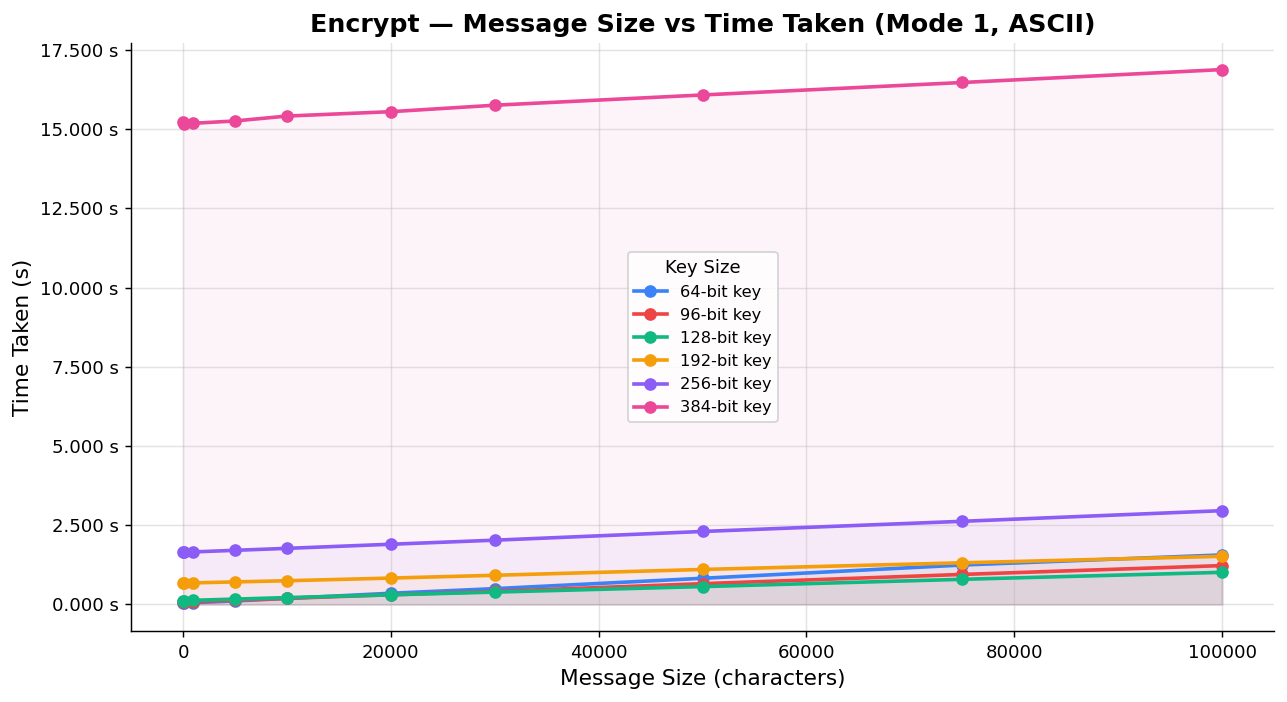

Saved → bench_encrypt.png


In [4]:
# ── Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

for idx, (bits, data) in enumerate(sorted(encrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if not valid:
        continue
    xs, ys = zip(*valid)
    color = COLOURS[idx % len(COLOURS)]
    ax.plot(xs, ys, "o-", color=color, linewidth=2,
            markersize=6, label=f"{bits}-bit key")
    ax.fill_between(xs, ys, alpha=0.06, color=color)

ax.set_xlabel("Message Size (characters)", fontsize=12)
ax.set_ylabel("Time Taken (s)", fontsize=12)
ax.set_title("Encrypt — Message Size vs Time Taken (Mode 1, ASCII)",
             fontsize=14, fontweight="bold")
ax.legend(title="Key Size", fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f s"))
plt.tight_layout()
plt.savefig("bench_encrypt.png", dpi=150)
plt.show()
print("Saved → bench_encrypt.png")

---
## 3  Decrypt — Ciphertext Size vs Time (multiple key sizes)

For each key size the corresponding ciphertext (produced above in the Encrypt step)  
is decrypted. A full round-trip (keygen → encrypt → decrypt) is done per configuration.

In [7]:
# Results: {bits: [(msg_chars, time), ...]}
decrypt_results = {}

for bits in KEY_BITS_TO_TEST:
    print(f"\n── Key size: {bits} bits ──")
    tmpdir = make_tmpdir()

    # 1. Generate keys
    _, kt = run_sage(["KeyGeneration.py", "3", str(bits), "1"], cwd=tmpdir)
    if kt is None:
        print(f"  Key generation FAILED — skipping.")
        cleanup(tmpdir)
        continue

    times = []
    for n in MSG_SIZES_BYTES:
        msg_file = tmpdir / "message.txt"
        make_message_file(msg_file, n)

        # 2. Encrypt once (to get ciphertext)
        _, et = run_sage(
            ["Encrypt.py", "1", "ecc_public_key.txt", "message.txt"],
            cwd=tmpdir
        )
        if et is None:
            print(f"  Encrypt FAILED for msg={n} — skipping.")
            times.append((n, None))
            continue

        # 3. Decrypt (RUNS times, take median)
        run_times = []
        for _ in range(RUNS):
            _, t = run_sage(
                ["Decrypt.py", "1",
                 "ecc_private_key.txt",
                 "ecc_public_key.txt",
                 "ecc_ciphertext.txt"],
                cwd=tmpdir
            )
            if t is not None:
                run_times.append(t)

        med = float(np.median(run_times)) if run_times else None
        times.append((n, med))
        status = f"{med:.3f}s" if med is not None else "FAILED"
        print(f"  msg={n:>5} chars  →  {status}")

    decrypt_results[bits] = times
    cleanup(tmpdir)

print("\n✓ Decrypt benchmark done")


── Key size: 64 bits ──
  msg=   10 chars  →  0.008s
  msg=  100 chars  →  0.009s
  msg= 1000 chars  →  0.019s
  msg= 5000 chars  →  0.061s
  msg=10000 chars  →  0.115s
  msg=20000 chars  →  0.216s
  msg=30000 chars  →  0.323s
  msg=50000 chars  →  0.535s
  msg=75000 chars  →  0.790s
  msg=100000 chars  →  1.049s

── Key size: 96 bits ──
  msg=   10 chars  →  0.012s
  msg=  100 chars  →  0.012s
  msg= 1000 chars  →  0.018s
  msg= 5000 chars  →  0.044s
  msg=10000 chars  →  0.076s
  msg=20000 chars  →  0.140s
  msg=30000 chars  →  0.203s
  msg=50000 chars  →  0.331s
  msg=75000 chars  →  0.496s
  msg=100000 chars  →  0.654s

── Key size: 128 bits ──
  msg=   10 chars  →  0.015s
  msg=  100 chars  →  0.016s
  msg= 1000 chars  →  0.020s
  msg= 5000 chars  →  0.039s
  msg=10000 chars  →  0.062s
  msg=20000 chars  →  0.111s
  msg=30000 chars  →  0.159s
  msg=50000 chars  →  0.252s
  msg=75000 chars  →  0.375s
  msg=100000 chars  →  0.494s

── Key size: 192 bits ──
  msg=   10 chars  →  0.0

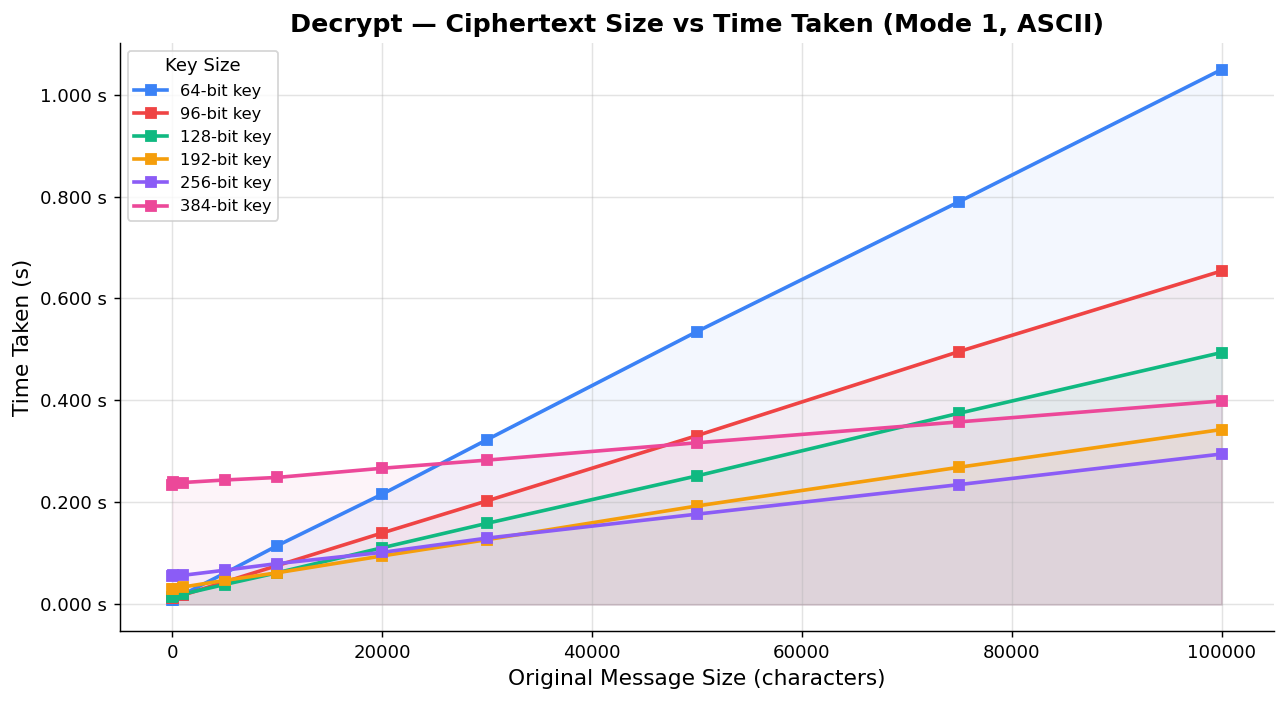

Saved → bench_decrypt.png


In [5]:
# ── Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

for idx, (bits, data) in enumerate(sorted(decrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if not valid:
        continue
    xs, ys = zip(*valid)
    color = COLOURS[idx % len(COLOURS)]
    ax.plot(xs, ys, "s-", color=color, linewidth=2,
            markersize=6, label=f"{bits}-bit key")
    ax.fill_between(xs, ys, alpha=0.06, color=color)

ax.set_xlabel("Original Message Size (characters)", fontsize=12)
ax.set_ylabel("Time Taken (s)", fontsize=12)
ax.set_title("Decrypt — Ciphertext Size vs Time Taken (Mode 1, ASCII)",
             fontsize=14, fontweight="bold")
ax.legend(title="Key Size", fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f s"))
plt.tight_layout()
plt.savefig("bench_decrypt.png", dpi=150)
plt.show()
print("Saved → bench_decrypt.png")

---
## 4  Combined Summary — All 3 Graphs Side by Side

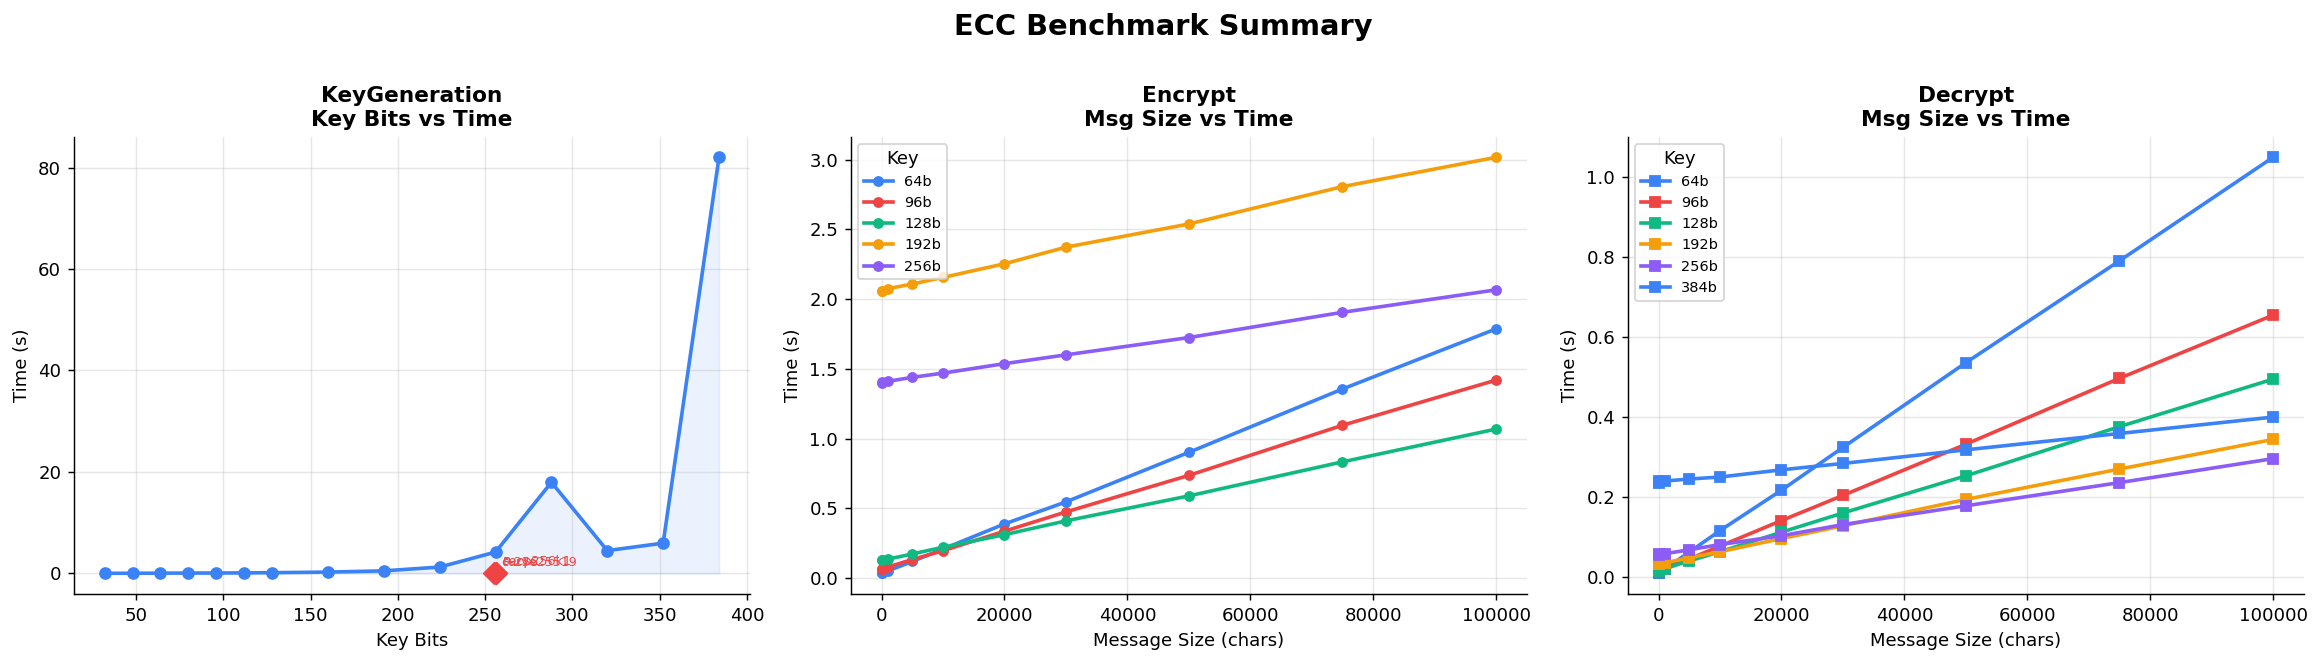

Saved → bench_summary.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ECC Benchmark Summary", fontsize=16, fontweight="bold", y=1.01)

# ── 1: KeyGen ──
ax = axes[0]
valid = [(b, t) for b, t in keygen_times if t is not None]
if valid:
    xs, ys = zip(*valid)
    ax.plot(xs, ys, "o-", color=COLOURS[0], linewidth=2, markersize=6)
    ax.fill_between(xs, ys, alpha=0.1, color=COLOURS[0])
for bits, t, name in predefined_pts:
    if t is not None:
        ax.scatter([bits], [t], zorder=5, s=70, marker="D", color=COLOURS[1])
        ax.annotate(name, (bits, t), textcoords="offset points",
                    xytext=(4, 4), fontsize=7, color=COLOURS[1])
ax.set_title("KeyGeneration\nKey Bits vs Time", fontweight="bold")
ax.set_xlabel("Key Bits")
ax.set_ylabel("Time (s)")

# ── 2: Encrypt ──
ax = axes[1]
for idx, (bits, data) in enumerate(sorted(encrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, "o-", color=COLOURS[idx % len(COLOURS)],
                linewidth=2, markersize=5, label=f"{bits}b")
ax.set_title("Encrypt\nMsg Size vs Time", fontweight="bold")
ax.set_xlabel("Message Size (chars)")
ax.set_ylabel("Time (s)")
ax.legend(title="Key", fontsize=8, loc="upper left")

# ── 3: Decrypt ──
ax = axes[2]
for idx, (bits, data) in enumerate(sorted(decrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, "s-", color=COLOURS[idx % len(COLOURS)],
                linewidth=2, markersize=5, label=f"{bits}b")
ax.set_title("Decrypt\nMsg Size vs Time", fontweight="bold")
ax.set_xlabel("Message Size (chars)")
ax.set_ylabel("Time (s)")
ax.legend(title="Key", fontsize=8, loc="upper left")

for a in axes:
    a.grid(True, alpha=0.3)
    a.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bench_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → bench_summary.png")

In [7]:
MSG_SIZES_BYTES = [10, 100, 1000, 5000, 10000, 20000, 30000, 50000, 75000, 100000]

# Key Generation benchmarking data
keygen_times = [
    (32, 0.012), (48, 0.013), (64, 0.036), (80, 0.057), 
    (96, 0.070), (112, 0.092), (128, 0.119), (160, 0.252), 
    (192, 0.717), (224, 0.946), (256, 2.037), (288, 2.384), 
    (320, 4.850), (352, 7.082), (384, 11.675)
]

# Encryption results
# Structured as: { key_bits: [(msg_size, time), ...] }
encrypt_results = {
    64: [(10, 0.035), (100, 0.037), (1000, 0.053), (5000, 0.110), (10000, 0.188), (20000, 0.352), (30000, 0.497), (50000, 0.824), (75000, 1.243), (100000, 1.562)],
    96: [(10, 0.072), (100, 0.074), (1000, 0.087), (5000, 0.133), (10000, 0.191), (20000, 0.304), (30000, 0.410), (50000, 0.654), (75000, 0.946), (100000, 1.225)],
    128: [(10, 0.116), (100, 0.120), (1000, 0.130), (5000, 0.167), (10000, 0.215), (20000, 0.302), (30000, 0.388), (50000, 0.562), (75000, 0.792), (100000, 1.012)],
    192: [(10, 0.665), (100, 0.669), (1000, 0.680), (5000, 0.710), (10000, 0.747), (20000, 0.831), (30000, 0.919), (50000, 1.103), (75000, 1.313), (100000, 1.518)],
    256: [(10, 1.648), (100, 1.653), (1000, 1.657), (5000, 1.707), (10000, 1.769), (20000, 1.899), (30000, 2.027), (50000, 2.302), (75000, 2.623), (100000, 2.959)],
    384: [(10, 15.212), (100, 15.171), (1000, 15.187), (5000, 15.260), (10000, 15.415), (20000, 15.553), (30000, 15.757), (50000, 16.081), (75000, 16.474), (100000, 16.882)]
}

# Decryption results
decrypt_results = {
    64: [(10, 0.008), (100, 0.009), (1000, 0.019), (5000, 0.061), (10000, 0.115), (20000, 0.216), (30000, 0.323), (50000, 0.535), (75000, 0.790), (100000, 1.049)],
    96: [(10, 0.012), (100, 0.012), (1000, 0.018), (5000, 0.044), (10000, 0.076), (20000, 0.140), (30000, 0.203), (50000, 0.331), (75000, 0.496), (100000, 0.654)],
    128: [(10, 0.015), (100, 0.016), (1000, 0.020), (5000, 0.039), (10000, 0.062), (20000, 0.111), (30000, 0.159), (50000, 0.252), (75000, 0.375), (100000, 0.494)],
    192: [(10, 0.031), (100, 0.031), (1000, 0.034), (5000, 0.047), (10000, 0.062), (20000, 0.095), (30000, 0.127), (50000, 0.193), (75000, 0.269), (100000, 0.343)],
    256: [(10, 0.055), (100, 0.057), (1000, 0.057), (5000, 0.067), (10000, 0.080), (20000, 0.102), (30000, 0.130), (50000, 0.177), (75000, 0.235), (100000, 0.295)],
    384: [(10, 0.234), (100, 0.240), (1000, 0.239), (5000, 0.244), (10000, 0.249), (20000, 0.267), (30000, 0.283), (50000, 0.317), (75000, 0.358), (100000, 0.399)]
}

---
## 5  Raw Results Table

In [8]:
import pandas as pd

# KeyGen table
df_kg = pd.DataFrame(keygen_times, columns=["Key Bits", "Time (s)"])
df_kg["Time (s)"] = df_kg["Time (s)"].map(lambda x: f"{x:.4f}" if x is not None else "—")
print("=== KeyGeneration ===")
print(df_kg.to_string(index=False))

# Encrypt / Decrypt tables
for label, results in [("Encrypt", encrypt_results), ("Decrypt", decrypt_results)]:
    rows = {"Msg Chars": MSG_SIZES_BYTES}
    for bits, data in sorted(results.items()):
        col = []
        d = dict(data)
        for n in MSG_SIZES_BYTES:
            t = d.get(n)
            col.append(f"{t:.4f}" if t is not None else "—")
        rows[f"{bits}b key"] = col
    df = pd.DataFrame(rows)
    print(f"\n=== {label} ===")
    print(df.to_string(index=False))

=== KeyGeneration ===
 Key Bits Time (s)
       32   0.0120
       48   0.0130
       64   0.0360
       80   0.0570
       96   0.0700
      112   0.0920
      128   0.1190
      160   0.2520
      192   0.7170
      224   0.9460
      256   2.0370
      288   2.3840
      320   4.8500
      352   7.0820
      384  11.6750

=== Encrypt ===
 Msg Chars 64b key 96b key 128b key 192b key 256b key 384b key
        10  0.0350  0.0720   0.1160   0.6650   1.6480  15.2120
       100  0.0370  0.0740   0.1200   0.6690   1.6530  15.1710
      1000  0.0530  0.0870   0.1300   0.6800   1.6570  15.1870
      5000  0.1100  0.1330   0.1670   0.7100   1.7070  15.2600
     10000  0.1880  0.1910   0.2150   0.7470   1.7690  15.4150
     20000  0.3520  0.3040   0.3020   0.8310   1.8990  15.5530
     30000  0.4970  0.4100   0.3880   0.9190   2.0270  15.7570
     50000  0.8240  0.6540   0.5620   1.1030   2.3020  16.0810
     75000  1.2430  0.9460   0.7920   1.3130   2.6230  16.4740
    100000  1.5620  1.2250 

---
## Notes

| Parameter | Value used | How to change |
|-----------|-----------|---------------|
| Repetitions per point | `RUNS = 3` (median) | Cell 1 |
| Key bit sizes | `KEY_BITS_TO_TEST` | Cell 5 |
| Message sizes | `MSG_SIZES_CHARS` | Cell 5 |
| KeyGen bit sweep | `BIT_SIZES` | Cell 3 |
| Timeout per run | `TIMEOUT = 600 s` | Cell 1 |

All timing values are taken directly from each script's own `Time Taken: X.XXXs` output,  
so they reflect **SageMath-internal** execution time, not subprocess overhead.